Fetching data for 2025-11-16...
✓ Found 30 KenPom predictions
✓ Found 33 games with odds
✓ Matched 5 games between both sources

Generating analysis...


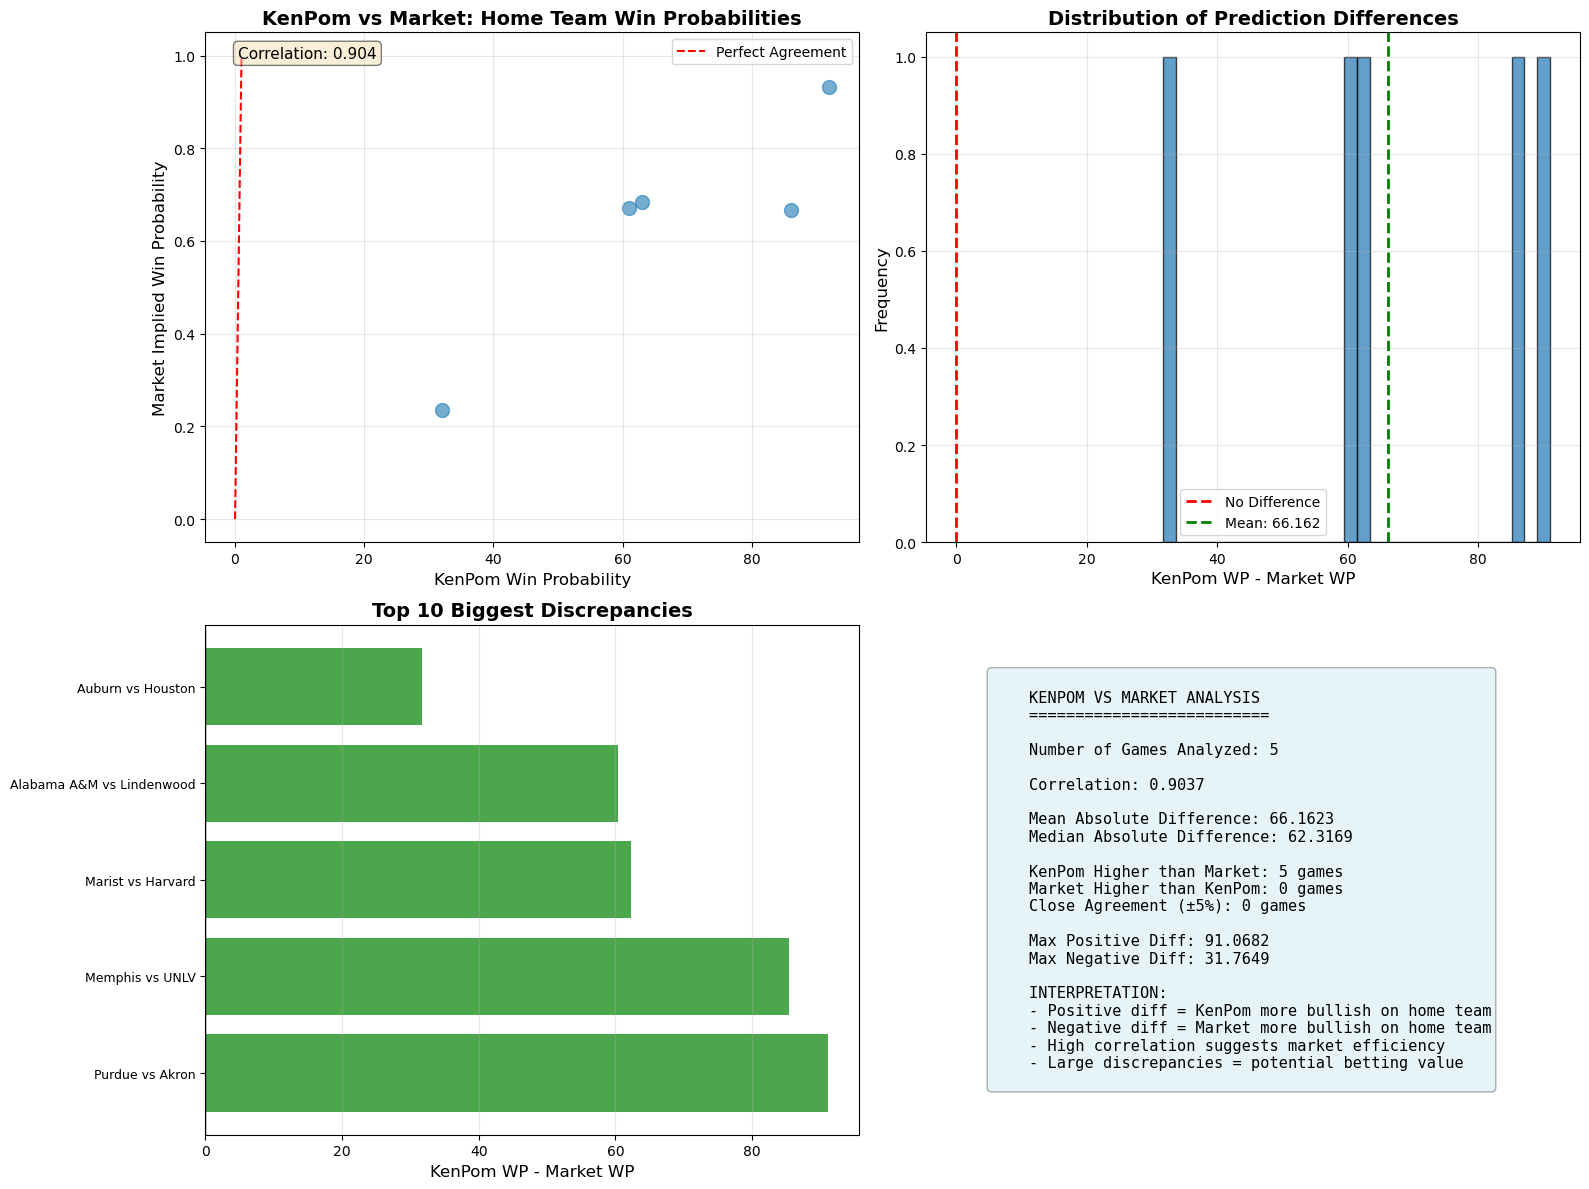


POTENTIAL VALUE BETS (>5% edge):
       Home       Away       Date                  Bet      Edge  KenPom_Home_WP  Market_Home_WP  Avg_Home_Odds  Avg_Away_Odds
     Purdue      Akron 2025-11-16 Home (KenPom favors) 91.068208              92        0.931792   -3328.571429    1307.142857
    Memphis       UNLV 2025-11-16 Home (KenPom favors) 85.333307              86        0.666693    -244.000000     182.000000
     Marist    Harvard 2025-11-16 Home (KenPom favors) 62.316892              63        0.683108    -268.000000     196.000000
Alabama A&M Lindenwood 2025-11-16 Home (KenPom favors) 60.328262              61        0.671738    -254.000000     185.200000
     Auburn    Houston 2025-11-16 Home (KenPom favors) 31.764906              32        0.235094     293.500000    -477.500000

✓ Results saved to kenpom_vs_market_2025-11-16.csv


In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ===== API CLIENTS =====

class KenPomAPI:
    def __init__(self, api_key):
        self.api_key = api_key
        self.base_url = 'https://kenpom.com/api.php'
        self.headers = {'Authorization': f'Bearer {api_key}'}
    
    def get_predictions(self, date):
        """Get KenPom game predictions for a date"""
        params = {'endpoint': 'fanmatch', 'd': date}
        response = requests.get(self.base_url, headers=self.headers, params=params)
        
        if response.status_code == 200:
            return pd.DataFrame(response.json())
        return None


class OddsAPI:
    def __init__(self, api_key):
        self.api_key = api_key
        self.base_url = 'https://api.the-odds-api.com/v4'
    
    def get_odds(self, sport='basketball_ncaab', regions='us', markets='h2h'):
        """Get current odds for college basketball"""
        url = f'{self.base_url}/sports/{sport}/odds'
        params = {
            'apiKey': self.api_key,
            'regions': regions,
            'markets': markets,
            'oddsFormat': 'american'
        }
        
        response = requests.get(url, params=params)
        
        if response.status_code == 200:
            return response.json()
        return None


# ===== ODDS CONVERSION =====

def american_to_probability(odds):
    """Convert American odds to implied probability"""
    if odds > 0:
        # Underdog: probability = 100 / (odds + 100)
        return 100 / (odds + 100)
    else:
        # Favorite: probability = |odds| / (|odds| + 100)
        return abs(odds) / (abs(odds) + 100)

def decimal_to_probability(odds):
    """Convert decimal odds to implied probability"""
    return 1 / odds


# ===== MATCH GAMES BETWEEN APIS =====

def normalize_team_name(name):
    """Normalize team names for matching"""
    # Remove common suffixes and standardize
    name = name.lower().strip()
    name = name.replace('state', 'st')
    name = name.replace('university', '')
    name = name.replace('college', '')
    return name.strip()

def match_games(kenpom_df, odds_data):
    """Match games between KenPom and Odds API"""
    matched_games = []
    
    for kp_game in kenpom_df.itertuples():
        kp_home = normalize_team_name(kp_game.Home)
        kp_away = normalize_team_name(kp_game.Visitor)
        
        # Find matching game in odds data
        for odds_game in odds_data:
            odds_home = normalize_team_name(odds_game['home_team'])
            odds_away = normalize_team_name(odds_game['away_team'])
            
            # Check if teams match
            if (kp_home in odds_home or odds_home in kp_home) and \
               (kp_away in odds_away or odds_away in kp_away):
                
                # Get average market odds across bookmakers
                home_odds_list = []
                away_odds_list = []
                
                for bookmaker in odds_game.get('bookmakers', []):
                    for market in bookmaker.get('markets', []):
                        if market['key'] == 'h2h':
                            for outcome in market['outcomes']:
                                if normalize_team_name(outcome['name']) in odds_home:
                                    home_odds_list.append(outcome['price'])
                                elif normalize_team_name(outcome['name']) in odds_away:
                                    away_odds_list.append(outcome['price'])
                
                if home_odds_list and away_odds_list:
                    # Average odds across bookmakers
                    avg_home_odds = np.mean(home_odds_list)
                    avg_away_odds = np.mean(away_odds_list)
                    
                    # Convert to probabilities
                    market_home_prob = american_to_probability(avg_home_odds)
                    market_away_prob = american_to_probability(avg_away_odds)
                    
                    # Normalize to remove vig (bookmaker margin)
                    total_prob = market_home_prob + market_away_prob
                    market_home_prob_fair = market_home_prob / total_prob
                    market_away_prob_fair = market_away_prob / total_prob
                    
                    matched_games.append({
                        'Home': kp_game.Home,
                        'Away': kp_game.Visitor,
                        'Date': kp_game.DateOfGame,
                        'KenPom_Home_WP': kp_game.HomeWP,
                        'KenPom_Away_WP': 1 - kp_game.HomeWP,
                        'Market_Home_WP': market_home_prob_fair,
                        'Market_Away_WP': market_away_prob_fair,
                        'KenPom_Home_Score': kp_game.HomePred,
                        'KenPom_Away_Score': kp_game.VisitorPred,
                        'Avg_Home_Odds': avg_home_odds,
                        'Avg_Away_Odds': avg_away_odds,
                        'Home_Rank': kp_game.HomeRank,
                        'Away_Rank': kp_game.VisitorRank
                    })
                    break
    
    return pd.DataFrame(matched_games)


# ===== VISUALIZATION =====

def plot_kenpom_vs_market(df):
    """Create comprehensive comparison visualizations"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Scatter plot: KenPom WP vs Market WP (Home teams)
    axes[0, 0].scatter(df['KenPom_Home_WP'], df['Market_Home_WP'], alpha=0.6, s=100)
    axes[0, 0].plot([0, 1], [0, 1], 'r--', label='Perfect Agreement')
    axes[0, 0].set_xlabel('KenPom Win Probability', fontsize=12)
    axes[0, 0].set_ylabel('Market Implied Win Probability', fontsize=12)
    axes[0, 0].set_title('KenPom vs Market: Home Team Win Probabilities', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Calculate correlation
    corr = df['KenPom_Home_WP'].corr(df['Market_Home_WP'])
    axes[0, 0].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                    transform=axes[0, 0].transAxes, fontsize=11,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2. Difference distribution
    df['Diff_Home'] = df['KenPom_Home_WP'] - df['Market_Home_WP']
    axes[0, 1].hist(df['Diff_Home'], bins=30, alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='No Difference')
    axes[0, 1].axvline(df['Diff_Home'].mean(), color='green', linestyle='--', 
                       linewidth=2, label=f'Mean: {df["Diff_Home"].mean():.3f}')
    axes[0, 1].set_xlabel('KenPom WP - Market WP', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Distribution of Prediction Differences', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Identify biggest discrepancies
    df['Abs_Diff'] = abs(df['Diff_Home'])
    top_discrepancies = df.nlargest(10, 'Abs_Diff')
    
    y_pos = np.arange(len(top_discrepancies))
    colors = ['green' if x > 0 else 'red' for x in top_discrepancies['Diff_Home']]
    
    axes[1, 0].barh(y_pos, top_discrepancies['Diff_Home'], color=colors, alpha=0.7)
    axes[1, 0].set_yticks(y_pos)
    axes[1, 0].set_yticklabels([f"{row['Home']} vs {row['Away']}" 
                                 for _, row in top_discrepancies.iterrows()], fontsize=9)
    axes[1, 0].set_xlabel('KenPom WP - Market WP', fontsize=12)
    axes[1, 0].set_title('Top 10 Biggest Discrepancies', fontsize=14, fontweight='bold')
    axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[1, 0].grid(alpha=0.3, axis='x')
    
    # 4. Summary statistics
    axes[1, 1].axis('off')
    summary_text = f"""
    KENPOM VS MARKET ANALYSIS
    ==========================
    
    Number of Games Analyzed: {len(df)}
    
    Correlation: {corr:.4f}
    
    Mean Absolute Difference: {df['Abs_Diff'].mean():.4f}
    Median Absolute Difference: {df['Abs_Diff'].median():.4f}
    
    KenPom Higher than Market: {(df['Diff_Home'] > 0.05).sum()} games
    Market Higher than KenPom: {(df['Diff_Home'] < -0.05).sum()} games
    Close Agreement (±5%): {(abs(df['Diff_Home']) <= 0.05).sum()} games
    
    Max Positive Diff: {df['Diff_Home'].max():.4f}
    Max Negative Diff: {df['Diff_Home'].min():.4f}
    
    INTERPRETATION:
    - Positive diff = KenPom more bullish on home team
    - Negative diff = Market more bullish on home team
    - High correlation suggests market efficiency
    - Large discrepancies = potential betting value
    """
    
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
                    verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    return df


# ===== IDENTIFY BETTING OPPORTUNITIES =====

def find_value_bets(df, threshold=0.05):
    """Find games where KenPom and market disagree significantly"""
    
    # KenPom thinks home team is undervalued
    kenpom_value = df[df['Diff_Home'] > threshold].copy()
    kenpom_value['Bet'] = 'Home (KenPom favors)'
    kenpom_value['Edge'] = kenpom_value['Diff_Home']
    
    # Market thinks home team is undervalued
    market_value = df[df['Diff_Home'] < -threshold].copy()
    market_value['Bet'] = 'Away (Market favors)'
    market_value['Edge'] = abs(market_value['Diff_Home'])
    
    value_bets = pd.concat([kenpom_value, market_value])
    value_bets = value_bets.sort_values('Edge', ascending=False)
    
    return value_bets[['Home', 'Away', 'Date', 'Bet', 'Edge', 
                       'KenPom_Home_WP', 'Market_Home_WP', 
                       'Avg_Home_Odds', 'Avg_Away_Odds']]


# ===== MAIN EXECUTION =====

if __name__ == "__main__":
    
    # Initialize APIs
    KENPOM_KEY = 'XXXX    ODDS_KEY = 'XXXX    
    kp = KenPomAPI(api_key=KENPOM_KEY)
    odds = OddsAPI(api_key=ODDS_KEY)
    
    # Get today's date
    today = datetime.today().strftime('%Y-%m-%d')
    
    print(f"Fetching data for {today}...")
    
    # Get KenPom predictions
    kenpom_predictions = kp.get_predictions(date=today)
    print(f"✓ Found {len(kenpom_predictions)} KenPom predictions")
    
    # Get betting odds
    odds_data = odds.get_odds(sport='basketball_ncaab')
    print(f"✓ Found {len(odds_data)} games with odds")
    
    # Match games
    matched_df = match_games(kenpom_predictions, odds_data)
    print(f"✓ Matched {len(matched_df)} games between both sources\n")
    
    if len(matched_df) == 0:
        print("No matching games found. Try a different date or check team name matching.")
    else:
        # Visualize comparison
        print("Generating analysis...")
        results_df = plot_kenpom_vs_market(matched_df)
        
        # Find value bets
        print("\n" + "="*70)
        print("POTENTIAL VALUE BETS (>5% edge):")
        print("="*70)
        value_bets = find_value_bets(results_df, threshold=0.05)
        
        if len(value_bets) > 0:
            print(value_bets.to_string(index=False))
        else:
            print("No significant edges found.")
        
        # Save results
        results_df.to_csv(f'kenpom_vs_market_{today}.csv', index=False)
        print(f"\n✓ Results saved to kenpom_vs_market_{today}.csv")